<a href="https://colab.research.google.com/github/bala-deensai/eos-ai-workshop/blob/main/HOUSE%20PRICE%20ESTIMATER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv("Housing.csv")

In [5]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [6]:
df.shape

(545, 13)

In [7]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


In [8]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [9]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [10]:
df = df.dropna()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop_duplicates()

In [13]:
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])

In [14]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["price"] >= lower) & (df["price"] <= upper)]

In [15]:
Q1 = df["area"].quantile(0.25)
Q3 = df["area"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["area"] >= lower) & (df["area"] <= upper)]

In [16]:
X = df.drop("price", axis=1)

y = df["price"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [19]:
y_pred = model.predict(X_test)

In [20]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 742678.2862974496


In [21]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 977664860283.9725


In [22]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 988769.3665784618


In [23]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.6667603355640939


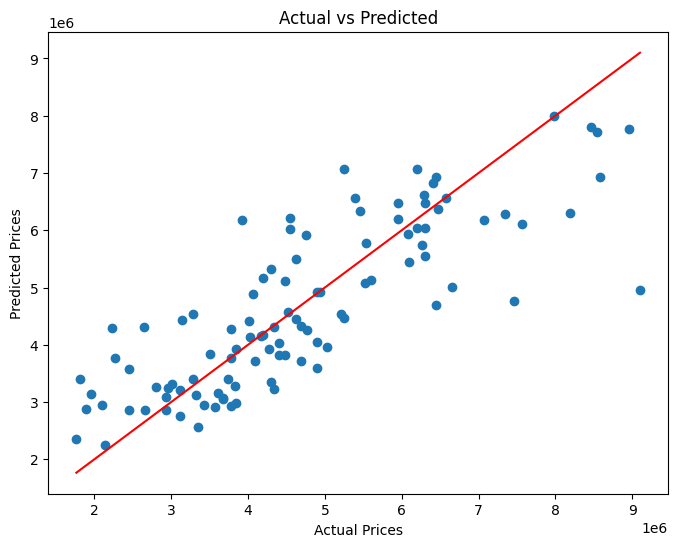

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")

plt.show()

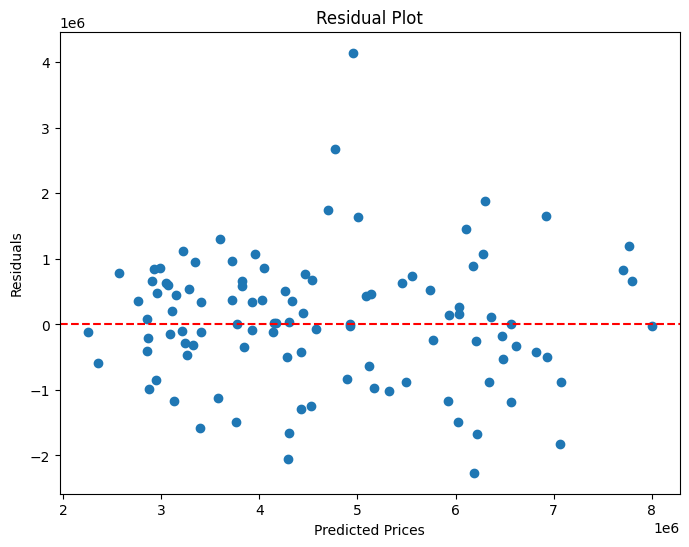

In [25]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [26]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

             Feature    Coefficient
0               area     246.671140
1           bedrooms  105670.701180
2          bathrooms  708587.258789
3            stories  457939.049080
4           mainroad  383891.965872
5          guestroom  409042.000579
6           basement  321022.688158
7    hotwaterheating  715671.433921
8    airconditioning  856376.605402
9            parking  220720.287546
10          prefarea  504920.719564
11  furnishingstatus -143431.807519


In [27]:
coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
8,airconditioning,856376.605402
7,hotwaterheating,715671.433921
2,bathrooms,708587.258789
10,prefarea,504920.719564
3,stories,457939.049080
5,guestroom,409042.000579
4,mainroad,383891.965872
6,basement,321022.688158
9,parking,220720.287546
1,bedrooms,105670.701180
